<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/12-Semana/Practica23_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Maestría en Inteligencia Artificial y Analítica de Datos

## Programación para Analítica Descriptiva y Predictiva - Octubre 2025
## Práctica: Regresión Lineal Simple con Scikit-Learn
---


## Datos del Estudiante

*   Apellidos y Nombre: Gámez Cortés Juan Francisco
*   Matrícula: 261554

---

## Objetivo de aprendizaje
Al finalizar esta práctica, el estudiante será capaz de **aplicar la regresión lineal simple utilizando Scikit-Learn para modelar la relación entre dos variables numéricas**, verificar los principales supuestos del modelo (linealidad, normalidad de residuos y homocedasticidad), **interpretar los coeficientes del modelo**, calcular e interpretar la **correlación entre variables** y evaluar el desempeño del modelo mediante métricas como el MSE, RMSE y R².


Trabajarás con el archivo restaurantes.csv, que contiene dos columnas:

- `poblation`: población de la ciudad (variable independiente). Tiene valores decimales mayores que cero. Estos valores representan la población de la ciudad multiplicada por 10,000. Por ejemplo, 6.1101 significa que la población de esa ciudad es 61,101.

- `profit`: ganancia del restaurante en esa ciudad (variable dependiente). Tiene valores decimales, algunos negativos y otros positivos. Estos representan las ganancias mensuales promedio de su restaurante en cada ciudad, en unidades de $10,000. Por ejemplo, 17.592 representa 175,920 en ganancias mensuales promedio para esa ciudad. -2.6807 representa -26,807 en pérdidas mensuales promedio para esa ciudad.





## 🔧 Parte 1: Carga de datos y bibliotecas
1. Importa las bibliotecas necesarias.
2. Carga el archivo `restaurantes.csv`
3. Muestra las primeras filas del dataframe.
4. Describe estadísticamente el conjunto de datos.

In [1]:
# Montar google drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [20]:
!pip install pingouin

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import pingouin as pg
from scipy import stats
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score



In [46]:
# Cargar el dataset
df = pd.read_csv('/content/drive/MyDrive/Unidad03/restaurantes.csv')
print(df.info())
print("\n")
print(df.head())
print("\n")
print(df.describe())
print("\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97 entries, 0 to 96
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   poblation  97 non-null     float64
 1   profit     97 non-null     float64
dtypes: float64(2)
memory usage: 1.6 KB
None


   poblation   profit
0     6.1101  17.5920
1     5.5277   9.1302
2     8.5186  13.6620
3     7.0032  11.8540
4     5.8598   6.8233


       poblation     profit
count  97.000000  97.000000
mean    8.159800   5.839135
std     3.869884   5.510262
min     5.026900  -2.680700
25%     5.707700   1.986900
50%     6.589400   4.562300
75%     8.578100   7.046700
max    22.203000  24.147000




##  Parte 2: Análisis exploratorio y relación entre variables

### 2.1 Diagrama de Dispersión
1. Grafica un **diagrama de dispersión** entre `poblation` y `profit`
2. Responde:  
**¿La relación entre las variables parece lineal? ¿Por qué?**

Sí hay una relación líneal entre las variables. En el gráfico podemos observar que a medida que se incrementa la población aumentan las ganancias promedio.

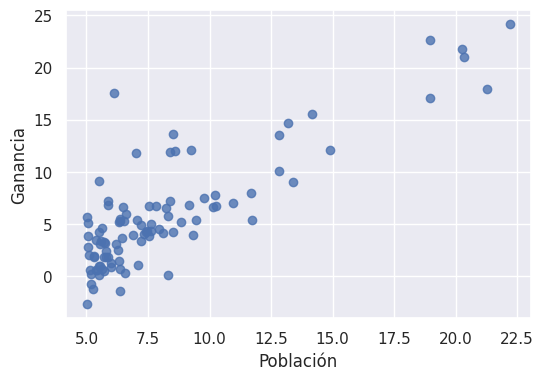

In [47]:
# Gráfico de dispersión entre poblation y profit
fig, ax = plt.subplots(1, 1, figsize=(6,4))
ax.scatter(x=df.poblation, y=df.profit, alpha= 0.8)
ax.set_xlabel('Población')
ax.set_ylabel('Ganancia');

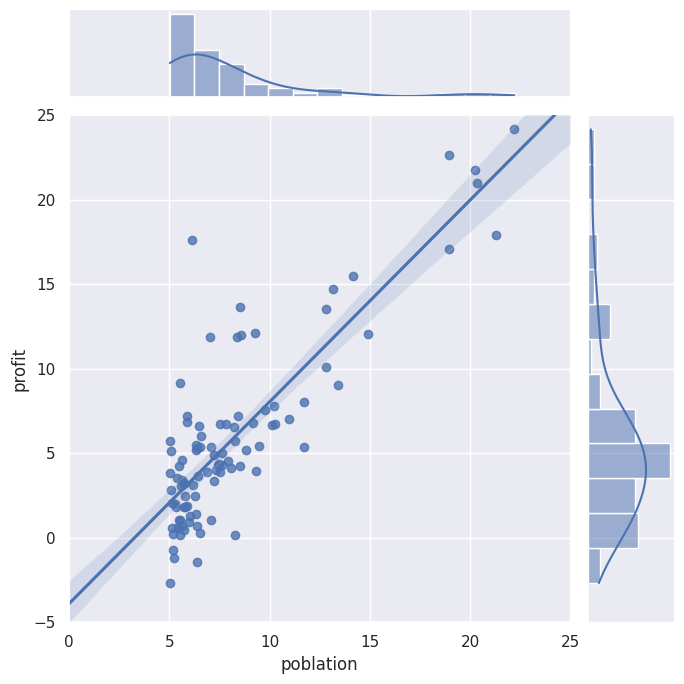

In [48]:
sns.set_theme(style="darkgrid")

sns.jointplot(x="poblation", y="profit", data=df,
                  kind="reg", truncate=False,
                  xlim=(0, 25), ylim=(-5, 25),
                  color="b", height=7)

### 2.2: Cálculo e interpretación de la correlación
1. Calcula e imprime el **coeficiente de correlación de Pearson** entre `poblation` y `profit`
2. Interpreta el resultado:
- ¿Qué tan fuerte es la relación?

`La relación es muy alta puesto que esta en 0.83`
- ¿Es positiva o negativa?

`Es una correlación positiva debido a que es un valor cercano a 1`
- ¿Es coherente con el gráfico anterior?

`Sí, es coherente ya que se confirma la correlación líneal`

In [49]:
# Cálculo de correlación Pearson
r, p = stats.pearsonr(df['poblation'], df['profit'])
print(f"Correlación Pearson: r={r}, p-value={p}")

Correlación Pearson: r=0.8378732325263409, p-value=1.0232099778760897e-26


In [50]:
# Cálculo de correlación, significancia e intervalos con pingouin
# Pearson
display(pg.corr(df['poblation'], df['profit'], method='pearson'))

,n,r,CI95%,p-val,BF10,power
pearson,97,0.837873,"[0.77, 0.89]",1.023210e-26,3.706e+23,1.0


## Parte 3: Construcción del modelo, coeficientes y visualización

###3.1 Construcción del modelo - obtención de los parámetros y coeficientes
1. Construye un modelo de regresión lineal simple usando las bibliotecas de Scikit-Learn
2. Imprime el intercepto y el coeficiente de la regresión (pendiente)
3. Interpreta el Intercepto: ¿Qué significa en términos del contexto del problema?

*  **Término independiente (intercepto): -3.89**:
   - Este es el valor de **Profit(Ganancias)** cuando la variable independiente poblacion es igual a 0. Es decir, el valor base de ganancias cuando población es cero. En este caso representa perdidas al no haber población.


4. Interpreta el coeficiente de la regresión (pendiente) ¿Qué significa en términos del contexto del problema?

*  **Coeficiente de Poblation: 1.19**:
   - Este coeficiente indica que, si **Poblation** aumenta en una unidad, el valor de las ganacias (**Profit**) aumenta en promedio en 1.19 unidades.
   - Es decir, a mayor  población (Poblation), las ganancias tienden a ser mayores.

In [51]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

In [52]:
# Construcción del modelo  y Coeficientes del modelo
# División de los datos en train y test
X = df[['poblation']]
y = df['profit']

# Construir y entrenar el modelo
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [53]:
#Obtener los Coeficientes y el Término Independiente:
coefficients = model.coef_
intercept = model.intercept_

print(f"\nCoeficientes estimados: {coefficients}")
print(f"Término independiente estimado (intercepto): {intercept}")
#######################################################
print('\n')
equation = f"Profit = {intercept} "
for i, coef in enumerate(coefficients):
  equation += f"+ ({coef} * {X.columns[i]}) "

equation #se obtiene el modelo con los coeficientes


Coeficientes estimados: [1.19303364]
Término independiente estimado (intercepto): -3.8957808783118484




'Profit = -3.8957808783118484 + (1.1930336441895932 * poblation) '

### 3.2 Visualización del modelo
1. Grafica los puntos originales (poblation vs profit) y dibuja la línea de regresión ajustada.
2. Asegúrate de incluir leyenda y títulos.

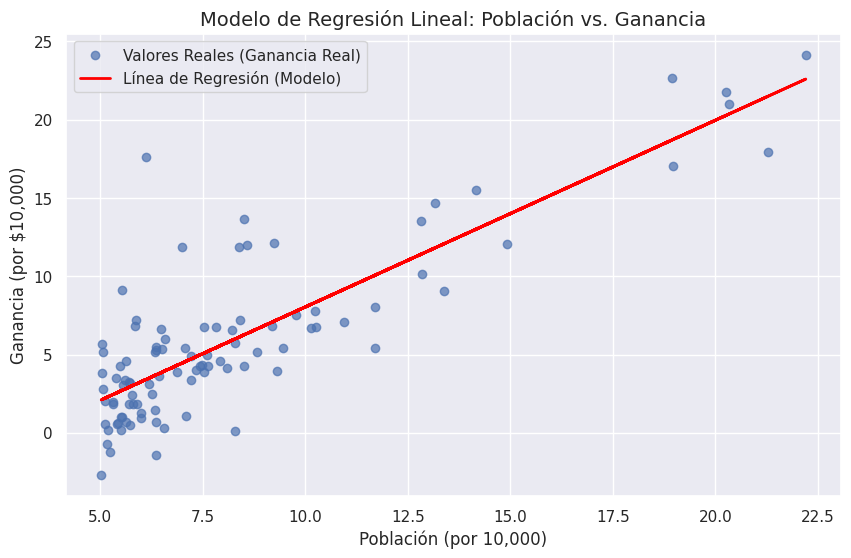

In [54]:
# Predicciones del modelo
y_pred = model.predict(X)

plt.figure(figsize=(10, 6))

# Graficar los puntos originales (Diagrama de Dispersión)
plt.scatter(X, y, alpha=0.7, label='Valores Reales (Ganancia Real)')

# Dibujar la línea de regresión ajustada
# Graficamos X vs. las predicciones de Y (y_pred)
plt.plot(X, y_pred, color='red', linewidth=2, label='Línea de Regresión (Modelo)')

# 3. Añadir leyenda y títulos
plt.title('Modelo de Regresión Lineal: Población vs. Ganancia', fontsize=14)
plt.xlabel('Población (por 10,000)', fontsize=12)
plt.ylabel('Ganancia (por $10,000)', fontsize=12)
plt.legend()
plt.grid(True)


## Parte 4: Supuestos del modelo de regresión lineal

### 4.1. Normalidad de los residuos
1. Calcula los residuos (reales - predichos).
2. Grafica un **histograma con KDE** de los residuos.
3. Responde: ¿Los residuos siguen una distribución normal?

Se observa que los residuos siguen una distribución normal con una ligera cola a la derecha

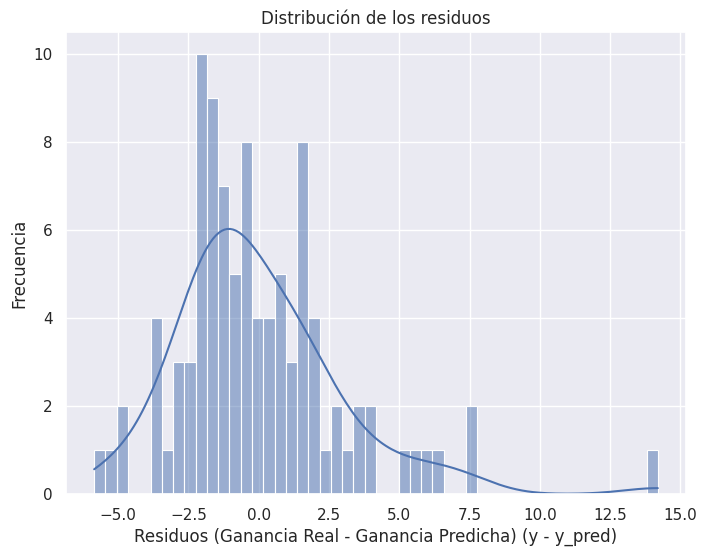

In [55]:
# Normalidad de los residuos
# Calcular los residuos del modelo
residuos = y - y_pred

# Histograma de residuos
plt.figure(figsize=(8, 6))
sns.histplot(residuos, bins=50, kde=True)
plt.xlabel("Residuos (Ganancia Real - Ganancia Predicha) (y - y_pred)")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.show()

### 4.2. Homocedasticidad
1. Grafica los residuos vs valores predichos.
2. ¿Los residuos están distribuidos aleatoriamente o muestran un patrón?

Los residuos estan dispersos y no se identifica un patrón, Se cumple el supuesto de homocedasticidad, se puede decir que, el modelo es igual de bueno prediciendo ganancias bajas que ganancias altas.

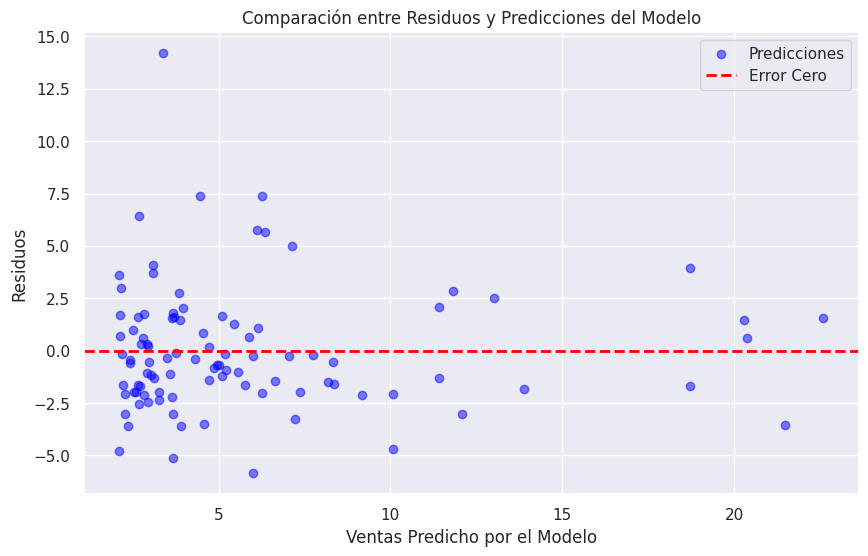


Comparación entre las predicciones y los residuos:
    Residuos  Predicción
0  14.198226    3.393774
1   6.431249    2.698951
2   7.394804    6.267196
3   7.394728    4.459272
4   3.728142    3.095158


In [56]:
# Homocedasticidad
# Graficar los residuos frente a las predicciones
plt.figure(figsize=(10, 6))

# Graficar los residuos vs las predicciones
plt.scatter(y_pred, residuos, alpha=0.5, color='blue', label='Predicciones')
# Añadir una línea horizontal en y=0 (línea de error cero)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Error Cero')

# Añadir título y etiquetas
plt.title("Comparación entre Residuos y Predicciones del Modelo")
plt.xlabel("Ventas Predicho por el Modelo")
plt.ylabel("Residuos")

# Añadir leyenda
plt.legend()

# Mostrar la gráfica
plt.show()

# Comparar los primeros valores reales con las predicciones
comparison_residuos = pd.DataFrame({
    'Residuos': residuos.head(),
    'Predicción': y_pred[:5]  # Primeras 5 predicciones
})

print("\nComparación entre las predicciones y los residuos:")
print(comparison_residuos)

### 4.3. Q-Q Plot para evaluar la normalidad
1. Grafica el Q-Q Plot:.
2. Interpreta el gráfico: a) Si los puntos se alinean aproximadamente sobre la línea diagonal, los residuos siguen una distribución normal y

Podemos observar que los residuos se situan cercanos a la diagonal por lo que podemos decir que siguen una distribución normal

b) Desviaciones sistemáticas indican asimetría o colas pesadas.

Se presentan desviaciones en los extremos que es señal de la presencia de colas.

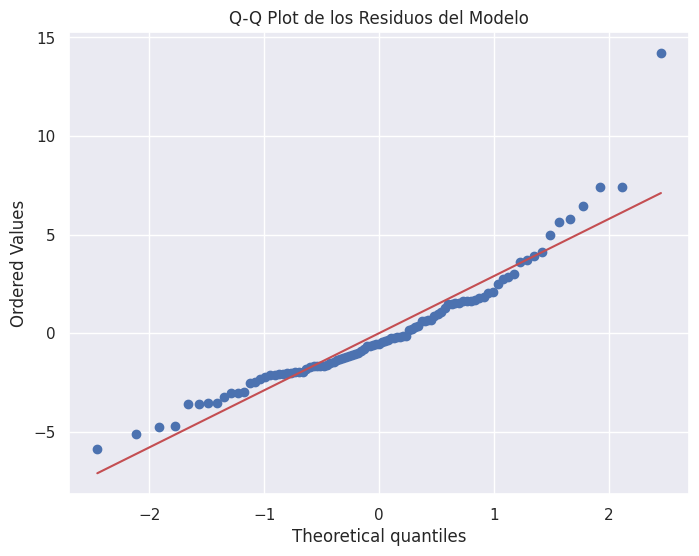

In [57]:
# Q-Q Plot
#  Graficar el Q-Q Plot
plt.figure(figsize=(8, 6))
stats.probplot(residuos, dist="norm", plot=plt)

# Añadir título
plt.title("Q-Q Plot de los Residuos del Modelo")

# Mostrar la gráfica
plt.show()

## Parte 5: Evaluación del modelo
1. Calcula las métricas:
- MSE
- RMSE
- R²
2. Interpreta: ¿Qué nos dicen sobre el ajuste del modelo?

*  **Error Cuadrático Medio (MSE): 8.9539**  
   El promedio de los errores al cuadrado entre los valores predichos y los valores reales nos emite un valor de **8.9539** indica que el modelo tiene un error moderado.

*  **Raíz del Error Cuadrático Medio (RMSE): 2.9923**  
   Un **RMSE de 2.9923** sugiere que, en promedio, las predicciones del modelo están a aproximadamente **2.9923** de los valores reales. Esto también indica que hay una diferencia moderada entre las predicciones y los valores observados.

*  **Coeficiente de Determinación (R²): 0.7020**  
   El R² mide la proporción de la varianza en la variable dependiente que es explicada por el modelo. Un **R² de 0.9026** indica que el modelo explica aproximadamente el **70.20% de la variabilidad** en los datos. Esto sugiere un **ajuste muy bueno**.

In [58]:
# Evaluación del modelo
# Calcular las métricas del modelo
mse = mean_squared_error(y, y_pred)  # Error cuadrático medio
rmse = np.sqrt(mse)  # Raíz del error cuadrático medio
mae = mean_absolute_error(y, y_pred)  # Error absoluto medio
r2 = r2_score(y, y_pred)  # Coeficiente de determinación R^2

# Mostrar las métricas
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.4f}")
print(f"Error Absoluto Medio (MAE): {mae:.4f}")
print(f"Coeficiente de Determinación (R²): {r2:.4f}")


Error Cuadrático Medio (MSE): 8.9539
Raíz del Error Cuadrático Medio (RMSE): 2.9923
Error Absoluto Medio (MAE): 2.1942
Coeficiente de Determinación (R²): 0.7020


## Parte 6: Conclusiones
Responde con tus propias palabras:
- ¿Qué tan útil consideras el modelo?

El modelo es bueno con un 70% de predicciones que pueden ser precisas, con una sola variable predictora, se puede confiar en sus resultados ya que la correlación entre variables es fuerte.

- ¿Qué limitaciones encuentras?

El 30 % de las ganancias no pueden ser predichas solo con la variable población, por lo cual se tiene un margen considerable de error, por lo que representa cierto riesgo para una decisión de inversión.

- ¿Crees que es necesario hacer un ajuste o estandarización a las variables dependientes o independientes?  Si crees que es necesario hacerlo realiza el ajuste.

Para casos de regresión lineal simple no se recomienda realizar estandarización debido a que la escala no afecta el rendimiento predictivo del modelo. Para interpretar la regresión simple en sus unidades originales, no se debe estandarizar.

